# Лабораторная работа № 1.1
## Статистические ряды распределения

**Выполнила:** Якупова Нелли, Елдашов Владислав

**Группа:** БИВТ-24-АЭ-3

Исходные данные — возраст людей, совершивших преступления в Москве в 2021 году.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

from pathlib import Path
file = next((candidate for candidate in [Path("ЛР-1.txt"), Path("data/ЛР-1.txt"), Path("../data/ЛР-1.txt")] if candidate.exists()), Path("ЛР-1.txt"))
if not file.exists():
    from google.colab import files
    uploaded = files.upload()
    file = Path(next(iter(uploaded)))
data = pd.read_table(file, header=None)[0]
N = len(data)
print("Количество наблюдений:", N)
print("Минимальный возраст:", data.min())
print("Максимальный возраст:", data.max())

Количество наблюдений: 32423
Минимальный возраст: 14
Максимальный возраст: 73

### 1. Дискретный и интервальный ряды распределения

In [2]:
discrete = data.value_counts().sort_index().rename_axis("x").reset_index(name="n")
discrete["w"] = discrete["n"] / N
discrete

Дискретный ряд
x | n | w
14 |   49 | 0.001511
15 |   53 | 0.001635
16 |  236 | 0.007279
17 |  126 | 0.003886
18 |  806 | 0.024859
19 |  971 | 0.029948
20 |  910 | 0.028066
21 |  716 | 0.022083
22 |  944 | 0.029115
23 | 1071 | 0.033032
24 |  810 | 0.024982
25 | 1050 | 0.032384
26 |  980 | 0.030225
27 | 1263 | 0.038954
28 | 1113 | 0.034327
29 | 1340 | 0.041329
30 |  734 | 0.022638
31 | 1115 | 0.034389
32 |  796 | 0.024550
33 |  758 | 0.023378
34 |  869 | 0.026802
35 |  676 | 0.020849
36 | 1198 | 0.036949
37 |  522 | 0.016100
38 | 1006 | 0.031027
39 |  695 | 0.021435
40 |  723 | 0.022299
41 |  837 | 0.025815
42 |  978 | 0.030164
43 |  820 | 0.025291
44 | 1032 | 0.031829
45 |  690 | 0.021281
46 |  677 | 0.020880
47 |  831 | 0.025630
48 | 1026 | 0.031644
49 | 1060 | 0.032693
50 |  150 | 0.004626
51 |  188 | 0.005798
52 |  193 | 0.005953
53 |   47 | 0.001450
54 |   26 | 0.000802
55 |   62 | 0.001912
56 |   76 | 0.002344
57 |  136 | 0.004195
58 |  262 | 0.008081
59 |   74 | 0.002282
60 |  266

In [3]:
k = 7
x_min = data.min()
x_max = data.max()
h = ceil((x_max - x_min) / k)
edges = [x_min + i*h for i in range(k+1)]

rows = []
for i in range(k):
    left, right = edges[i], edges[i+1]
    if i < k-1:
        count = ((data >= left) & (data < right)).sum()
    else:
        count = ((data >= left) & (data <= right)).sum()
    rows.append({"x_min": left, "x_max": right, "x_middle": (left+right)/2, "n": count})

interval = pd.DataFrame(rows)
interval["w"] = interval["n"] / N
print("Число групп:", k, "; ширина интервала:", h)
interval

Интервальный ряд (k=7, h=9)
x_min | x_max | x_middle | n | w
   14 |    23 |     18.5 |  4811 | 0.1484
   23 |    32 |     27.5 |  9476 | 0.2923
   32 |    41 |     36.5 |  7243 | 0.2234
   41 |    50 |     45.5 |  7951 | 0.2452
   50 |    59 |     54.5 |  1140 | 0.0352
   59 |    68 |     63.5 |  1472 | 0.0454
   68 |    77 |     72.5 |   330 | 0.0102

### 2. Статистические характеристики

In [4]:
def mean_value(x, n):
    return (x*n).sum()/n.sum()

def dispersion(x, n, mean):
    return (((x-mean)**2)*n).sum()/n.sum()

def standard_deviation(D):
    return D**0.5

def coefficient_of_variation(sigma, mean):
    return sigma/mean*100

def mode_value(x, n):
    i = n.idxmax()
    return x.loc[i], n.loc[i]

def median_value(x, n):
    cumulative = n.cumsum()
    N = n.sum()
    values = []
    for position in [(N-1)//2, N//2]:
        i = cumulative.searchsorted(position+1)
        values.append(x.iloc[i])
    return sum(values)/2

def print_stats(name, x, n, mean, D, sigma, mode, mode_n, median, minimum, maximum):
    print(name)
    print(f"Средняя: {mean:.3f}")
    print(f"Дисперсия: {D:.3f}")
    print(f"СКО: {sigma:.3f}")
    print(f"Коэффициент вариации: {coefficient_of_variation(sigma, mean):.2f}%")
    print(f"Мода: {mode}; частота: {mode_n}")
    print(f"Медиана: {median:.3f}")
    print(f"Минимум: {minimum}; максимум: {maximum}")
    print(f"Размах: {maximum-minimum}")

Функции для расчёта характеристик рядов определены.

In [5]:
# Дискретный ряд
x = discrete["x"]
n = discrete["n"]
mean_d = mean_value(x, n)
D_d = dispersion(x, n, mean_d)
sigma_d = standard_deviation(D_d)
mode_d, mode_n_d = mode_value(x, n)
median_d = median_value(x, n)
print_stats("Дискретный ряд", x, n, mean_d, D_d, sigma_d, mode_d, mode_n_d, median_d, x.min(), x.max())

# Интервальный ряд: характеристики приближённые, по серединам интервалов
x_i = interval["x_middle"]
n_i = interval["n"]
mean_i = mean_value(x_i, n_i)
D_i = dispersion(x_i, n_i, mean_i)
sigma_i = standard_deviation(D_i)
j = n_i.idxmax()
n_prev = n_i.iloc[j-1] if j > 0 else 0
n_next = n_i.iloc[j+1] if j < len(n_i)-1 else 0
mode_i = interval.loc[j, "x_min"] + h*(n_i.iloc[j]-n_prev)/(2*n_i.iloc[j]-n_prev-n_next)
mode_n_i = n_i.iloc[j]
cumulative = n_i.cumsum()
jm = cumulative.searchsorted(N/2)
previous = cumulative.iloc[jm-1] if jm > 0 else 0
median_i = interval.loc[jm, "x_min"] + h*(N/2-previous)/n_i.iloc[jm]
print()
print_stats("Интервальный ряд (оценка)", x_i, n_i, mean_i, D_i, sigma_i, round(mode_i, 3), mode_n_i, median_i, interval["x_min"].min(), interval["x_max"].max())

Дискретный ряд
Средняя: 35.373
Дисперсия: 144.917
СКО: 12.038
Коэффициент вариации: 34.03%
Мода: 29; частота: 1340
Медиана: 34.000
Минимум: 14; максимум: 73
Размах: 59

Интервальный ряд (оценка)
Средняя: 35.631
Дисперсия: 148.536
СКО: 12.188
Коэффициент вариации: 34.20%
Мода: 29.087; частота: 9476
Медиана: 34.391
Минимум: 14; максимум: 77
Размах: 63

### 3. Графики частот

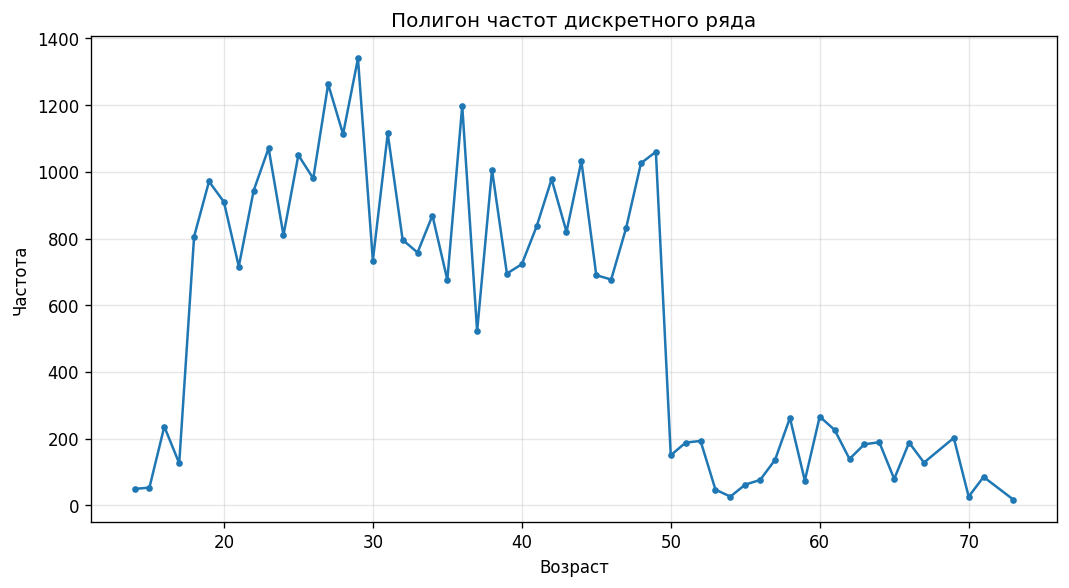

In [6]:
plt.figure(figsize=(9,5))
plt.plot(discrete["x"], discrete["n"], marker="o")
plt.title("Полигон частот дискретного ряда")
plt.xlabel("Возраст"); plt.ylabel("Частота")
plt.grid(alpha=0.3); plt.show()

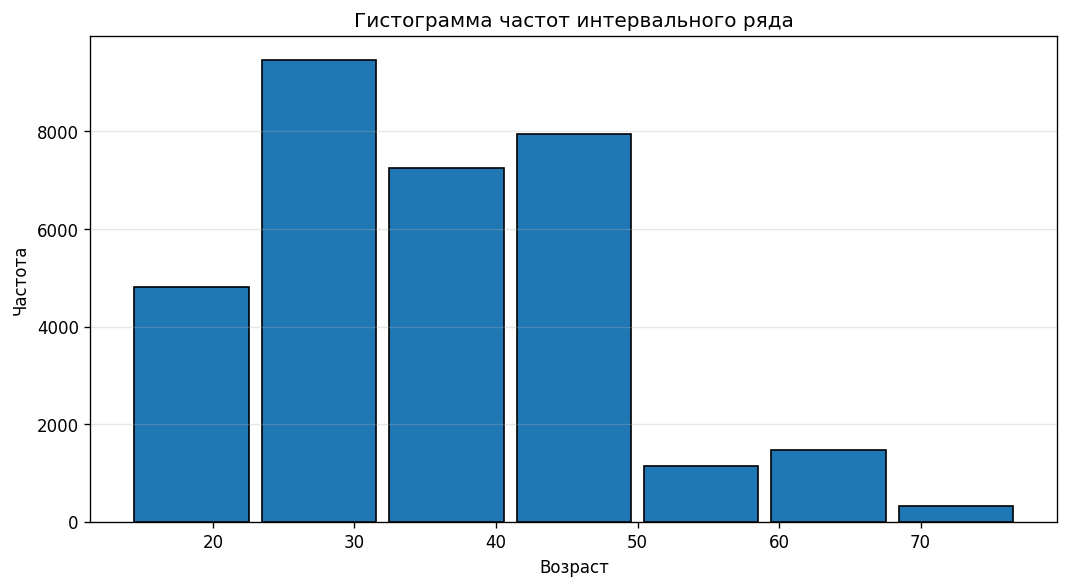

In [7]:
plt.figure(figsize=(9,5))
plt.bar(interval["x_middle"], interval["n"], width=h*0.9, edgecolor="black")
plt.title("Гистограмма частот интервального ряда")
plt.xlabel("Возраст"); plt.ylabel("Частота")
plt.grid(axis="y", alpha=0.3); plt.show()

### Вывод

По выборке объёмом 32423 наблюдений построены дискретный ряд и интервальный ряд из 7 групп. Средний возраст по дискретному ряду составляет 35.37 года, мода — 29 лет, медиана — 34 лет. Построены полигон частот и гистограмма. Характеристики интервального ряда являются приближёнными.